In [1]:
import warnings
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from mfsindy.cases.lorenz import (
    LorenzMultiTrajectoryGLSConfig,
    fit_lorenz_multi_trajectory_rollout_models,
    generate_lorenz_dataset,
    run_lorenz_multi_trajectory_gls_experiment,
)
from mfsindy.cases.lorenz_plots import COLORS_MODELS
from mfsindy.experiments import (
    evaluate_rollout_models,
    format_model_equations,
    make_metric_scorer,
    optimize_hyperparams,
    split_trajectory_list,
)
from mfsindy.plots import bubble_hist

warnings.filterwarnings("ignore")
sns.set(context="paper", style="white")

RESULTS_DIR = Path("results")
if not RESULTS_DIR.exists():
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
elif not RESULTS_DIR.is_dir():
    raise NotADirectoryError(f"{RESULTS_DIR} exists and is not a directory")

MODELS = ["HF", "LF", "MF", "MF_w"]
PLOT_ORDER = ["MF_w", "MF", "HF", "LF"]

cfg = LorenzMultiTrajectoryGLSConfig(
    n_runs=5,
    results_dir=str(RESULTS_DIR),
    results_filename="lorenz_part1_errors.csv",
)


# Lorenz Part 1 — Multi-trajectory GLS

This notebook compares high- and low-fidelity ensembles for the Lorenz system using the multi-trajectory (Part 1) workflow.

## Governing equations

The classic Lorenz-63 dynamics are

$$
\begin{align*}
\dot{x} &= \sigma (y - x), \\
\dot{y} &= x (\rho - z) - y, \\
\dot{z} &= x y - \beta z.
\end{align*}
$$

We use $(\sigma,\rho,\beta) = (10, 28, 8/3)$ with $n_{HF}$ high-fidelity and $n_{LF}$ low-fidelity trajectories.


### Trajectory snapshot
Preview noisy LF/HF trajectories and a clean reference.

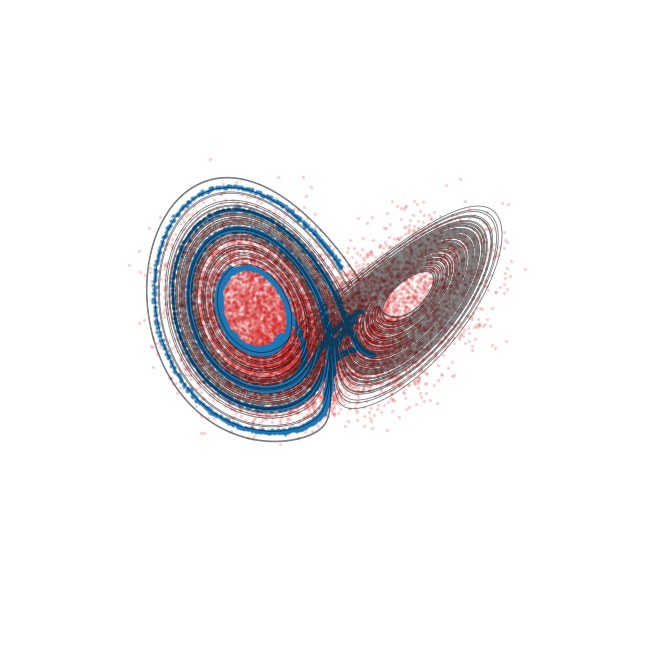

In [2]:
from mfsindy.cases.lorenz_plots import plot_multifidelity_trajectories
X_clean, _, _ = generate_lorenz_dataset(
    n_traj=1,
    T=cfg.T_true,
    dt=cfg.dt,
    noise_level=0.0,
    seed=cfg.seed_base,
)
X_hf_batch, t_train, _ = generate_lorenz_dataset(
    n_traj=cfg.n_hf,
    T=cfg.T_train*10,
    dt=cfg.dt,
    noise_level=cfg.noise_hf_rel*np.std(X_clean),
    seed=cfg.seed_base + 5,
)
X_lf_batch, _, _ = generate_lorenz_dataset(
    n_traj=cfg.n_lf,
    T=cfg.T_train*10,
    dt=cfg.dt,
    noise_level=cfg.noise_lf_rel*np.std(X_clean),
    seed=cfg.seed_base + 125,
)
plot_multifidelity_trajectories(X_hf_batch, X_lf_batch, X_clean)




### Hyperparameter Selection

Use one noisy HF/LF dataset instance, split the trajectories 80-20, tune the weak-form hyperparameters by maximizing held-out rollout $R^2$ for `MF_w`, then refit all four models on that same dataset and print the resulting equations.


In [ ]:
SEARCH_GRID = {
    "stlsq_threshold": [0.05, 0.1, 0.2],
    "poly_degree": [2],
    "H_xt": [0.005, 0.01, 0.02],
}

search_state_std = float(np.std(X_clean))
X_hf_search, t_search, _ = generate_lorenz_dataset(
    n_traj=cfg.n_hf,
    T=cfg.T_train,
    dt=cfg.dt,
    noise_level=cfg.noise_hf_rel * search_state_std,
    seed=cfg.seed_base,
)
X_lf_search, _, _ = generate_lorenz_dataset(
    n_traj=cfg.n_lf,
    T=cfg.T_train,
    dt=cfg.dt,
    noise_level=cfg.noise_lf_rel * search_state_std,
    seed=cfg.seed_base + 100,
)

hf_train, hf_val = split_trajectory_list(X_hf_search, validation_fraction=0.2)
lf_train, lf_val = split_trajectory_list(X_lf_search, validation_fraction=0.2)

search_results = {}
best_params_by_model = {}
tuned_cfg_by_model = {}
tuned_models = {}

for target_model in MODELS:
    search = optimize_hyperparams(
        cfg,
        param_grid=SEARCH_GRID,
        evaluate=lambda candidate_cfg, target_model=target_model: evaluate_rollout_models(
            fit_lorenz_multi_trajectory_rollout_models(
                candidate_cfg,
                hf_trajectories=hf_train,
                lf_trajectories=lf_train,
                t_grid=t_search,
                weak_seed=candidate_cfg.seed_base + 40_000,
            ),
            {"HF validation": hf_val, "LF validation": lf_val},
            t_grid=t_search,
        ),
        score_fn=make_metric_scorer(source=target_model, metric="rollout_r2"),
        maximize=True,
    )
    tuned_cfg = deepcopy(search.best_config)
    search_results[target_model] = search
    best_params_by_model[target_model] = search.best_params
    tuned_cfg_by_model[target_model] = tuned_cfg
    tuned_models[target_model] = fit_lorenz_multi_trajectory_rollout_models(
        tuned_cfg,
        hf_trajectories=X_hf_search,
        lf_trajectories=X_lf_search,
        t_grid=t_search,
        weak_seed=tuned_cfg.seed_base + 40_001,
    )[target_model]

print(pd.DataFrame(best_params_by_model).T)
print(format_model_equations(tuned_models, precision=3))


9it [03:33, 23.71s/it]
9it [03:24, 22.76s/it]
9it [03:33, 23.74s/it]
9it [03:34, 23.82s/it]


      stlsq_threshold  poly_degree  H_xt
HF               0.05          2.0  0.02
LF               0.10          2.0  0.01
MF               0.10          2.0  0.01
MF_w             0.10          2.0  0.02
HF
x_dot = -8.97 x + 9.74 y - 0.0244 x^2 - 0.0378 x z + 0.00777 y z
y_dot = 3.52 x + 5.54 y + 0.222 x^2 + 0.0707 x y - 0.264 y z
z_dot = 0.0501 y - 2.66 z + 1 x y

LF
x_dot = -0.674 x + 8.99 y + 0.115 x^2 + 0.143 x y - 0.353 x z
y_dot = 13.8 x - 2.23 y - 0.151 x^2 - 0.41 x z + 0.0716 y z
z_dot = 7.04 x - 5.6 y - 3.11 z + 0.427 x^2 + 0.946 x y - 0.293 x z + 0.235 y z

MF
x_dot = -1.46 x + 8.95 y + 0.119 x y - 0.347 x z
y_dot = 14.1 x - 0.885 y - 0.15 x^2 - 0.422 x z
z_dot = 6.23 x - 5.24 y - 3.06 z + 0.396 x^2 + 0.946 x y - 0.25 x z + 0.225 y z

MF_w
x_dot = -9.96 x + 9.97 y
y_dot = 28.7 x - 1.03 y - 1.03 x z
z_dot = -2.68 z + 1.03 x y


### Run

In [4]:
df_errors_parts = []
for model_name in MODELS:
    method_cfg = deepcopy(tuned_cfg_by_model[model_name])
    method_cfg.results_dir = str(RESULTS_DIR)
    method_cfg.results_filename = f"lorenz_part1_{model_name.lower()}_errors.csv"
    df_model, _, _, _, _, _ = run_lorenz_multi_trajectory_gls_experiment(method_cfg)
    df_errors_parts.append(df_model[df_model["model"] == model_name].copy())

df_errors = pd.concat(df_errors_parts, ignore_index=True)
df_errors.to_csv(Path(cfg.results_dir) / cfg.results_filename, index=False)

def metric_values(metric: str) -> dict[str, np.ndarray]:
    return {
        m: df_errors[(df_errors["model"] == m) & (df_errors["metric"] == metric)]["value"].to_numpy()/27
        for m in MODELS
    }

def summarise(errors: dict[str, np.ndarray]) -> pd.DataFrame:
    rows = []
    for model, values in errors.items():
        arr = np.asarray(values, dtype=float)
        if arr.size == 0:
            continue
        rows.append(
            {
                "model": model,
                "median": float(np.median(arr)),
                "q25": float(np.percentile(arr, 25.0)),
                "q75": float(np.percentile(arr, 75.0)),
            }
        )
    return pd.DataFrame(rows).set_index("model")

mae_errors = metric_values("MAE")
l0_errors = metric_values("L0")
mae_summary = summarise(mae_errors)
l0_summary = summarise(l0_errors)

print("Mean Absolute Error")
print(mae_summary)
print("Support Fraction Error")
print(l0_summary)


Monte Carlo Lorenz MF: 100%|██████████| 5/5 [02:41<00:00, 32.29s/it]

Mean Absolute Error
         median       q25       q75
model                              
HF     0.047339  0.044879  0.052445
LF     0.059260  0.046815  0.066706
MF     0.055029  0.040531  0.056070
MF_w   0.000542  0.000268  0.001064
Support Fraction Error
         median       q25       q75
model                              
HF     0.047619  0.047619  0.052910
LF     0.068783  0.052910  0.068783
MF     0.063492  0.058201  0.068783
MF_w   0.000000  0.000000  0.000000


### Error summaries
Bubble histograms summarise the MAE and $L_0$ distributions across methods.


In [1]:
method_colors = {m: COLORS_MODELS.get(m, "tab:gray") for m in MODELS}
labels = ["WMF", "MF", "HF", "LF"]

bubble_hist(
    errors_dict=mae_errors,
    xlabel="MAE",
    n_bins=20,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

bubble_hist(
    errors_dict=l0_errors,
    xlabel=r"$L_0$",
    n_bins=12,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)



NameError: name 'MODELS' is not defined